In [ ]:
import subprocess

input_file = "/content/test/chern_voice.m4a"
output_file = "/content/test/chern_voice.wav"

subprocess.run([
    "ffmpeg",
    "-i", input_file,
    "-ar", "16000",      # sampling rate
    "-ac", "1",          # mono
    output_file
])

CompletedProcess(args=['ffmpeg', '-i', '/content/test/chern_voice.m4a', '-ar', '16000', '-ac', '1', '/content/test/chern_voice.wav'], returncode=0)

In [ ]:
!pip install -q noisereduce


In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="biodatlab/whisper-th-medium-combined",
    local_dir="/content/model"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

'/content/model'

# 🎙️ ASR Pipeline — Automatic Speech Recognition ภาษาไทย


### 🔍 หลักการทำงานของ ASR

```
🎤 เสียงพูด (Audio)
       ↓
🧹 Pre-processing (ลด Noise, ปรับคุณภาพเสียง)
       ↓
📊 Feature Extraction (สกัด Feature จากเสียง เช่น Mel Spectrogram)
       ↓
🤖 ASR Model (Whisper, Wav2Vec2, ฯลฯ)
       ↓
📝 ข้อความ (Transcribed Text)
```

### 🛠️ โมเดลที่ใช้ใน Pipeline นี้

| โมเดล | ขนาด | จุดเด่น |
|-------|------|--------|
| **Thonburian Whisper** (`whisper-th-medium-combined`) | Medium | เร็ว, เหมาะกับข้อความต่อเนื่อง |
| **Pathumma-Whisper** (`Pathumma-whisper-th-large-v3`) | Large-v3 | แม่นยำสูง, รองรับภาษาไทยดี |

### 🧩 ภาพรวม Pipeline ใน Notebook นี้

```
Section 1 → Check env
Section 2 → โหลดและฟังไฟล์เสียง
Section 3 → Noise Reduction (ลดเสียงรบกวน)
Section 4 → Visualize เสียง (Waveform & Spectrogram)
Section 5 → ASR: ถอดเสียงเป็นข้อความ (Single File)
Section 6 → ASR: ถอดเสียงแบบ Batch (หลายไฟล์พร้อมกัน)
Section 7 → Full Pipeline: Denoise + ASR (Production Ready)
```

---
## ⚙️ Section 1: Check env

In [ ]:
!nvidia-smi

In [ ]:
import torch

# ตรวจสอบ PyTorch version และ CUDA availability
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Device      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM Total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# กำหนดค่า device และ dtype ที่จะใช้ทั่ว notebook
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print(f"\nUsing device    : {DEVICE}")
print(f"Using dtype     : {TORCH_DTYPE}")

---
## 🔊 Section 2: โหลดและฟังไฟล์เสียง

ก่อน process เสียง เราต้องรู้จักข้อมูลเสียงก่อน:

| คำศัพท์ | ความหมาย | ค่าทั่วไป |
|---------|-----------|----------|
| **Sample Rate (sr)** | จำนวน sample ต่อวินาที | 16,000 Hz (Whisper), 48,000 Hz (ClearVoice) |
| **Waveform (y)** | ค่าแอมพลิจูดของเสียงในแต่ละ sample | array ของตัวเลข -1.0 ถึง 1.0 |
| **Duration** | ความยาวของเสียง (วินาที) | `len(y) / sr` |

### Library ที่ใช้
- **`librosa`** — Library ยอดนิยมสำหรับวิเคราะห์เสียงใน Python
- **`IPython.display.Audio`** — แสดง audio player ใน Jupyter Notebook

In [ ]:
import os
import librosa
import numpy as np
from IPython.display import Audio, display

# ====================================================
# 📁 กำหนด Path ไปยังโฟลเดอร์ที่เก็บไฟล์เสียง
# ====================================================
AUDIO_FOLDER = "/content/test"

# ดึงรายชื่อไฟล์ .wav ทั้งหมดในโฟลเดอร์
file_list = sorted([f for f in os.listdir(AUDIO_FOLDER) if f.endswith('.wav')])
print(f"พบไฟล์เสียงทั้งหมด: {len(file_list)} ไฟล์")
print(f"\nตัวอย่าง 5 ไฟล์แรก:")
for f in file_list[:5]:
    print(f"  - {f}")

พบไฟล์เสียงทั้งหมด: 1 ไฟล์

ตัวอย่าง 5 ไฟล์แรก:
  - chern_voice.wav


In [ ]:
# ====================================================
# 🎵 เลือกไฟล์และโหลดข้อมูลเสียง
# ====================================================
INDEX = 0  # เปลี่ยนตัวเลขนี้เพื่อเลือกไฟล์อื่น

selected_file = file_list[INDEX]
file_path = os.path.join(AUDIO_FOLDER, selected_file)

# librosa.load() โหลดเสียงเป็น numpy array
# sr=None = ใช้ sample rate เดิมของไฟล์ (ไม่ resample)
y, sr = librosa.load(file_path, sr=None)

# แสดงข้อมูลเสียง
print(f"ไฟล์           : {selected_file}")
print(f"Sample Rate    : {sr} Hz")
print(f"Duration       : {len(y)/sr:.2f} วินาที")
print(f"Waveform shape : {y.shape}")
print(f"\n🔊 ฟังเสียงต้นฉบับ:")

# แสดง audio player ใน Notebook
display(Audio(file_path))

ไฟล์           : chern_voice.wav
Sample Rate    : 16000 Hz
Duration       : 21.08 วินาที
Waveform shape : (337237,)

🔊 ฟังเสียงต้นฉบับ:


---
## 🧹 Section 3: Noise Reduction — ลดเสียงรบกวน

เสียงในชีวิตจริงมักมี **Noise** (เสียงรบกวน) ปนอยู่เสมอ เช่น เสียงแอร์, เสียงรถ, เสียงพัดลม ทำให้โมเดล ASR แปลผิดพลาดได้

### เทคนิค Noise Reduction ที่ใช้ใน Pipeline นี้

#### 🔵 วิธีที่ 1: Spectral Subtraction (`noisereduce`)
- **แนวคิด**: วิเคราะห์ spectrum ของ noise จากส่วนที่ "เงียบ" ของเสียง แล้วลบออกจาก spectrum ทั้งหมด
- **ข้อดี**: ง่าย เร็ว ไม่ต้องใช้ GPU
- **`prop_decrease=0.8`** = ลด noise ลง 80%

#### 🟡 วิธีที่ 2: Wavelet Denoising
- **แนวคิด**: แยกเสียงออกเป็น "ชั้น" ความถี่ต่างๆ ด้วย Wavelet Transform แล้วลบ noise จากชั้นความถี่สูง
- **ข้อดี**: รักษาเสียงพูด (ความถี่กลาง) ไว้ได้ดี
- **`wavelet='db4'`** = ใช้ Daubechies wavelet ระดับ 4



In [ ]:
import noisereduce as nr

# ====================================================
# 🔵 วิธีที่ 1: Spectral Subtraction
# ====================================================
# nr.reduce_noise() ใช้หลักการ Spectral Subtraction
# y       = waveform ที่โหลดมา
# sr      = sample rate
# prop_decrease = สัดส่วนการลด noise (0.0 - 1.0)

noise_reduced = nr.reduce_noise(y=y, sr=sr, prop_decrease=0.8)

print("✅ Spectral Subtraction เสร็จแล้ว")
print(f"Output shape: {noise_reduced.shape}")
print("\n🔊 ฟังหลัง Spectral Subtraction:")
display(Audio(noise_reduced, rate=sr))

✅ Spectral Subtraction เสร็จแล้ว
Output shape: (337237,)

🔊 ฟังหลัง Spectral Subtraction:


In [ ]:
import pywt

# ====================================================
# 🟡 วิธีที่ 2: Wavelet Denoising
# ====================================================
def wavelet_denoise(data, wavelet='db4', level=1):
    """
    ลด noise ด้วย Wavelet Thresholding

    Parameters:
    -----------
    data    : numpy array ของ waveform
    wavelet : ชนิด wavelet ('db4' = Daubechies 4)
    level   : จำนวนชั้นที่จะ decompose

    Returns:
    --------
    numpy array ของ waveform หลังลด noise
    """
    # 1. แยกสัญญาณออกเป็นหลายชั้น (Wavelet Decomposition)
    coeff = pywt.wavedec(data, wavelet, mode="per")

    # 2. คำนวณ threshold จาก median absolute deviation
    sigma = np.median(np.abs(coeff[-level])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(data))) * 0.3  # ค่า 0.3 = conservative threshold

    # 3. ลบ noise จากชั้นความถี่สูง (high-frequency layers)
    #    ชั้น 0 = low frequency (เสียงพูดหลัก) → ไม่แตะ
    #    ชั้น 1+ = high frequency (noise) → ทำ soft thresholding
    for i in range(1, len(coeff)):
        if i >= level:
            coeff[i] = pywt.threshold(coeff[i], value=uthresh, mode='soft')

    # 4. รวมสัญญาณกลับคืน (Wavelet Reconstruction)
    return pywt.waverec(coeff, wavelet, mode="per")


# รัน wavelet denoising ต่อจาก spectral subtraction
# (ใช้ noise_reduced จาก cell ก่อนหน้าเป็น input)
denoised_audio = wavelet_denoise(noise_reduced)

print("✅ Wavelet Denoising เสร็จแล้ว")
print(f"Output shape: {denoised_audio.shape}")
print("\n🔊 ฟังหลัง Wavelet Denoising (Combined):")
display(Audio(denoised_audio, rate=sr))

✅ Wavelet Denoising เสร็จแล้ว
Output shape: (337238,)

🔊 ฟังหลัง Wavelet Denoising (Combined):


---
## 📊 Section 4: Visualize เสียง — เปรียบเทียบก่อน/หลัง Denoise

การแสดงผลเสียงในรูปแบบกราฟช่วยให้เข้าใจว่า Denoising มีผลต่อเสียงอย่างไร

### กราฟที่ใช้เปรียบเทียบ

| กราฟ | แสดงอะไร | ประโยชน์ |
|------|----------|----------|
| **Waveform** | Amplitude ตามเวลา | เห็นว่าเสียงมีช่วงเงียบ/ดัง ตอนไหน |
| **Spectrogram (STFT)** | ความเข้มของความถี่ตามเวลา | เห็น noise pattern |
| **Mel Spectrogram** | เหมือน Spectrogram แต่ scale ตามการได้ยินของมนุษย์ | Feature ที่ ASR ใช้จริง |
| **FFT Spectrum** | ความเข้มของแต่ละความถี่ | เห็นว่า noise อยู่ที่ความถี่ไหน |

/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/529028489.py:54: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt

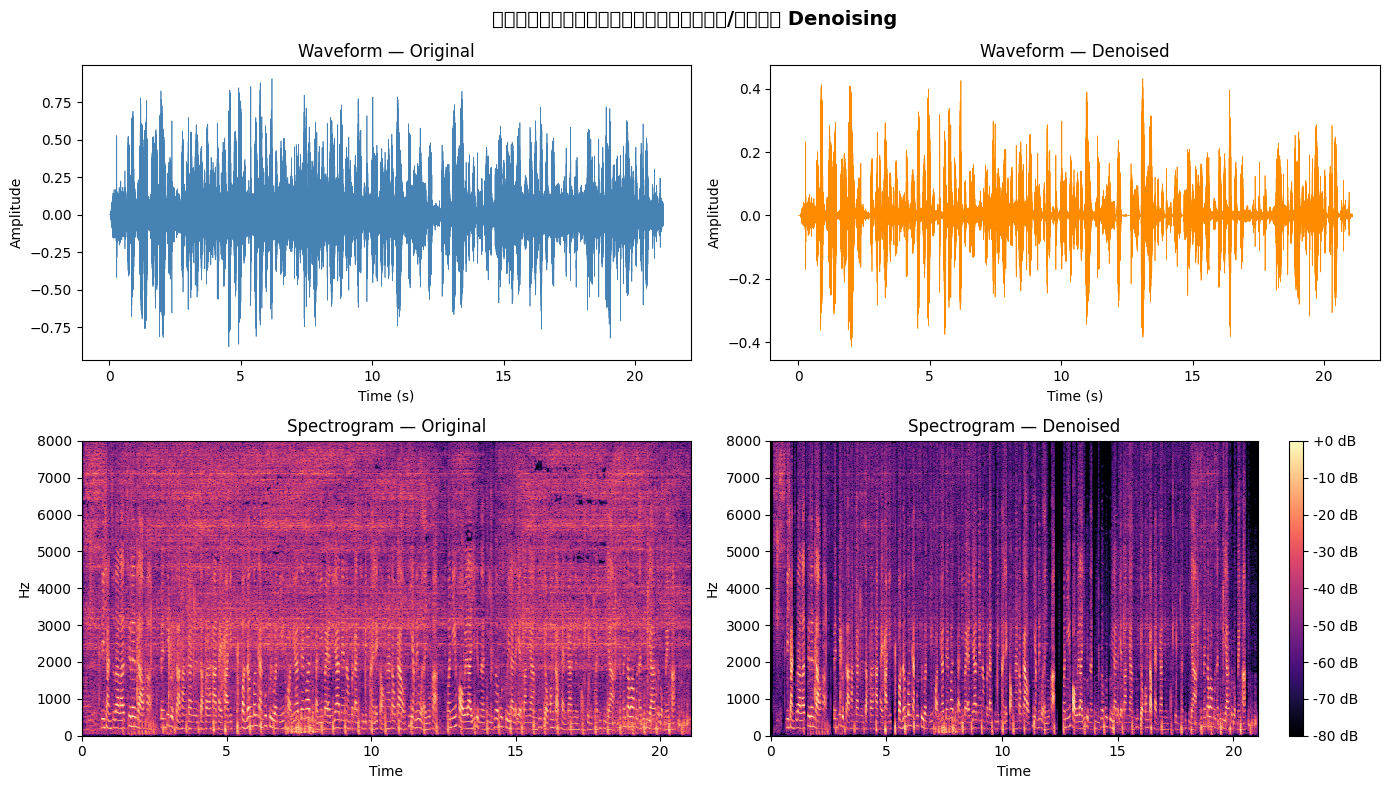

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# ====================================================
# 📊 เปรียบเทียบ Waveform + Spectrogram: ก่อน vs หลัง Denoise
# ====================================================

# โหลดเสียงต้นฉบับ
audio_before, sr_before = librosa.load(file_path, sr=None)

# ใช้ผลลัพธ์จากการลด noise ด้วย Wavelet Denoising (ซึ่งเป็นตัวแปรที่ถูกสร้างและมีอยู่)
audio_after = denoised_audio
sr_after = sr # Sample rate ควรจะเหมือนเดิมหลังจาก wavelet denoising

# ปรับให้ยาวเท่ากัน
if sr_before != sr_after:
    audio_after = librosa.resample(audio_after, orig_sr=sr_after, target_sr=sr_before)
    sr_after = sr_before

min_len = min(len(audio_before), len(audio_after))
audio_before = audio_before[:min_len]
audio_after  = audio_after[:min_len]

def plot_audio_comparison(audio1, audio2, sr, label1="Original", label2="Denoised"):
    """วาดกราฟเปรียบเทียบเสียงสองไฟล์ (Waveform + Spectrogram)"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("เปรียบเทียบเสียงก่อน/หลัง Denoising", fontsize=14, fontweight='bold')

    time = np.linspace(0, len(audio1) / sr, len(audio1))

    # --- Waveform: Original ---
    axes[0, 0].plot(time, audio1, color='steelblue', linewidth=0.5)
    axes[0, 0].set_title(f'Waveform — {label1}')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')

    # --- Waveform: Denoised ---
    axes[0, 1].plot(time, audio2, color='darkorange', linewidth=0.5)
    axes[0, 1].set_title(f'Waveform — {label2}')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Amplitude')

    # --- Spectrogram: Original ---
    D1 = librosa.amplitude_to_db(np.abs(librosa.stft(audio1)), ref=np.max)
    librosa.display.specshow(D1, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 0])
    axes[1, 0].set_title(f'Spectrogram — {label1}')

    # --- Spectrogram: Denoised ---
    D2 = librosa.amplitude_to_db(np.abs(librosa.stft(audio2)), ref=np.max)
    im = librosa.display.specshow(D2, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 1])
    axes[1, 1].set_title(f'Spectrogram — {label2}')
    fig.colorbar(im, ax=axes[1, 1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()


plot_audio_comparison(audio_before, audio_after, sr_before)

/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2175/20491503.py:34: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_la

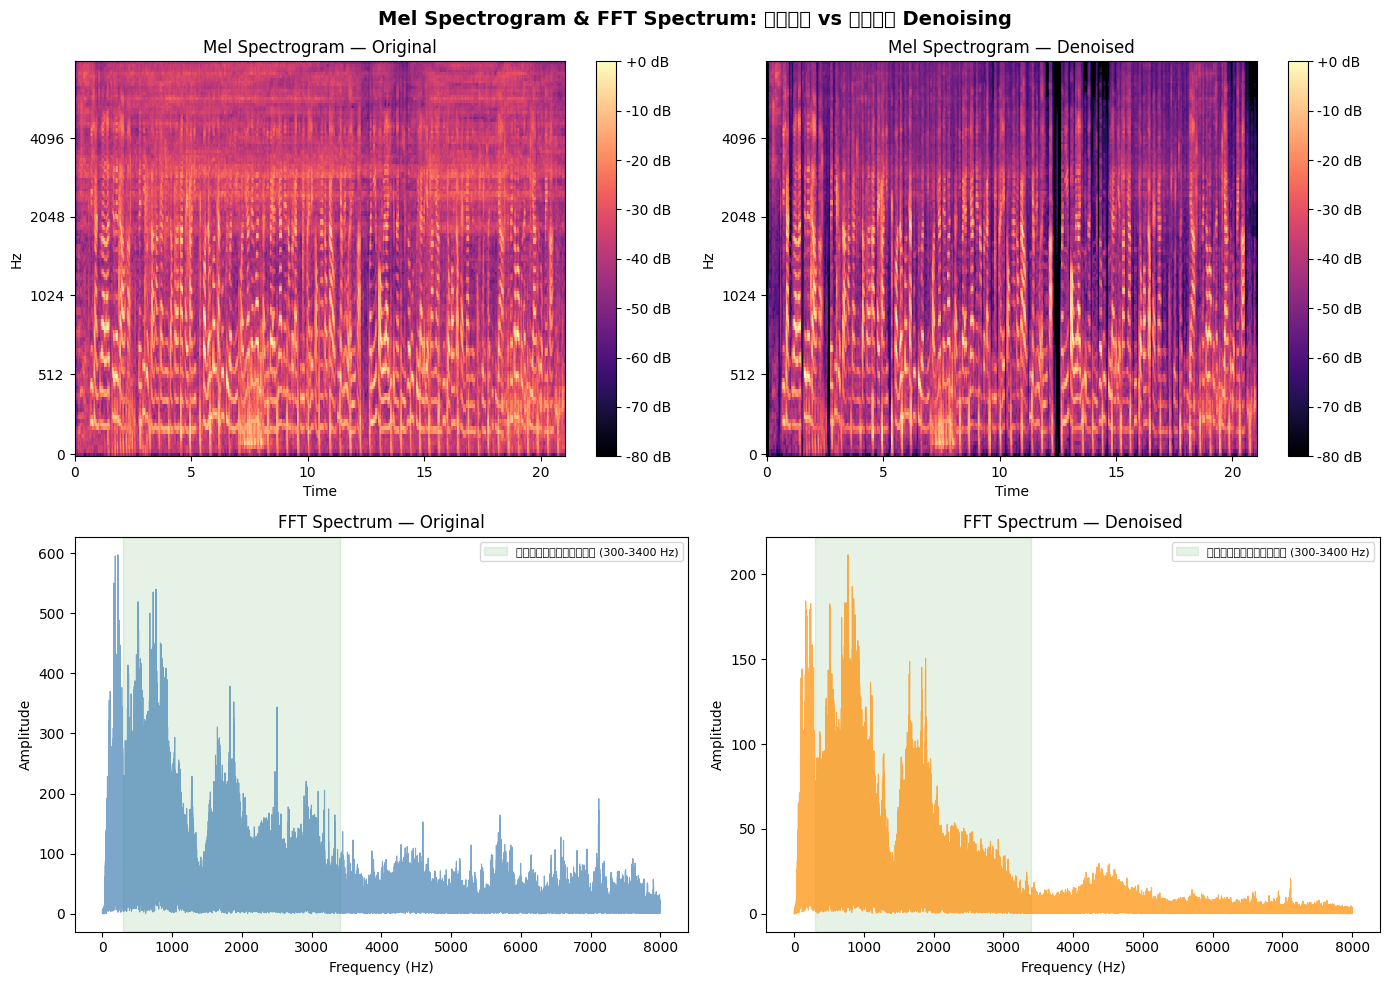

💡 สังเกต: หลัง Denoising ความเข้มของ noise ที่ความถี่สูง (>4000 Hz) ควรลดลงอย่างเห็นได้ชัด


In [ ]:
# ====================================================
# 📊 Mel Spectrogram + FFT: ก่อน vs หลัง Denoise
# ====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mel Spectrogram & FFT Spectrum: ก่อน vs หลัง Denoising", fontsize=14, fontweight='bold')

# --- Mel Spectrogram ---
for ax, audio, sr_val, title, color in [
    (axes[0, 0], audio_before, sr_before, "Mel Spectrogram — Original",  None),
    (axes[0, 1], audio_after,  sr_after,  "Mel Spectrogram — Denoised",  None),
]:
    mel = librosa.feature.melspectrogram(y=audio, sr=sr_val, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr_val, x_axis='time', y_axis='mel', fmax=8000, ax=ax)
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

# --- FFT Spectrum ---
for ax, audio, sr_val, title, color in [
    (axes[1, 0], audio_before, sr_before, "FFT Spectrum — Original", 'steelblue'),
    (axes[1, 1], audio_after,  sr_after,  "FFT Spectrum — Denoised", 'darkorange'),
]:
    fft_vals = np.abs(np.fft.rfft(audio))
    fft_freq = np.fft.rfftfreq(len(audio), d=1/sr_val)
    ax.plot(fft_freq, fft_vals, color=color, alpha=0.7, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    # ไฮไลต์ช่วงความถี่เสียงพูด (300-3400 Hz)
    ax.axvspan(300, 3400, alpha=0.1, color='green', label='ช่วงเสียงพูด (300-3400 Hz)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("💡 สังเกต: หลัง Denoising ความเข้มของ noise ที่ความถี่สูง (>4000 Hz) ควรลดลงอย่างเห็นได้ชัด")

---
## 🤖 Section 5: ASR — ถอดเสียงเป็นข้อความ (Single File)

ในส่วนนี้เราจะทดลองใช้โมเดล ASR สองตัวเพื่อเปรียบเทียบผลลัพธ์

### Whisper คืออะไร?

**Whisper** คือโมเดล ASR ที่พัฒนาโดย OpenAI รองรับกว่า 99 ภาษา ทำงานด้วยหลักการ **Encoder-Decoder Transformer**:

```
Audio Input
    → Mel Spectrogram (Feature Extraction)
    → Encoder (เข้าใจเสียง)
    → Decoder (สร้างข้อความทีละ token)
    → Text Output
```

### Parameter สำคัญ

| Parameter | ค่าที่ใช้ | ความหมาย |
|-----------|-----------|----------|
| `chunk_length_s` | 20 | แบ่งเสียงออกเป็น chunk ละ 20 วินาที |
| `batch_size` | 16 | ประมวลผล 16 chunk พร้อมกัน |
| `language` | `th` | ระบุภาษาไทย |
| `task` | `transcribe` | ถอดความ (ไม่ใช่แปลภาษา) |

In [ ]:
from transformers import pipeline as hf_pipeline

# ====================================================
# 🔵 โมเดลที่ 1: Thonburian Whisper (Medium)
# ====================================================
# เหมาะสำหรับ: งานที่ต้องการความเร็ว, ทรัพยากรจำกัด
# ขนาดโมเดล: ~769M parameters

THONBURIAN_MODEL = "/content/model"

pipe_thonburian = hf_pipeline(
    task="automatic-speech-recognition",
    model=THONBURIAN_MODEL,
    chunk_length_s=20,    # แบ่งเสียงเป็น chunk ละ 20 วินาที
    #device=DEVICE,
)

print(f"✅ โหลด Thonburian Whisper เสร็จแล้ว")

Loading weights:   0%|          | 0/948 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to proj_out.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ โหลด Thonburian Whisper เสร็จแล้ว


NameError: name 'DEVICE' is not defined

In [ ]:
# ====================================================
# 🎯 ถอดเสียงด้วย Thonburian Whisper
# ====================================================

# input: file_path = ไฟล์เสียงที่เลือกไว้ใน Section 2
# generate_kwargs: ส่ง argument เพิ่มเติมให้ model.generate()
result_thonburian = pipe_thonburian(
    file_path,
    batch_size=16,
    return_timestamps=False,  # ไม่ต้องการ timestamp ของแต่ละคำ
    generate_kwargs={
        "language": "<|th|>",  # บังคับให้โมเดล decode เป็นภาษาไทย
        "task": "transcribe"   # transcribe = ถอดความ (ไม่แปลภาษา)
    }
)["text"]

print("📝 Thonburian Whisper Result:")
print("-" * 50)
print(result_thonburian)

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


📝 Thonburian Whisper Result:
--------------------------------------------------
ดิฉัน สุดาลัด ชื่อเล่นดาวน์ค่ะเป็นที่ปรึกษาทางการเงินจากธนาคารไทยพาณิชย์ก่อนเริ่มต้นการพูดคุยวันนี้ขออนุญาตแจ้งว่าดิฉันมีใบอนุญาตแนะนำประกันชีวิตหมายเลขสองห้าเก้าเก้าที่ยังไม่หมดอายุค่ะวันนี้ขอเวลายี่สิบนาทีเพื่อพูดคุยรายละเอียดบางอย่างที่เกี่ยวข้องกับแผนการเงินของคุณอธิซิยา ไม่ทราบว่าคุณอธิซิยาสะดวกไหมคะ


In [ ]:
# ====================================================
# 🟢 โมเดลที่ 2: Pathumma-Whisper (Large-v3)
# ====================================================
# เหมาะสำหรับ: งานที่ต้องการความแม่นยำสูง
# ขนาดโมเดล: ~1.5B parameters
# ใช้ bfloat16 เพื่อลด VRAM โดยไม่เสีย accuracy มาก

PATHUMMA_MODEL = "/project/ai901504-ai0004/501328_chern/week4/Pathumma-whisper-th-large-v3"

pipe_pathumma = hf_pipeline(
    task="automatic-speech-recognition",
    model=PATHUMMA_MODEL,
    chunk_length_s=20,
    torch_dtype=TORCH_DTYPE,  # bfloat16 บน GPU, float32 บน CPU
    device=DEVICE,
    batch_size=16
)

# ตั้งค่า forced_decoder_ids เพื่อบังคับให้โมเดล decode เป็นภาษาไทย
# วิธีนี้เร็วกว่าการส่ง language ใน generate_kwargs ทุกครั้ง
pipe_pathumma.model.config.forced_decoder_ids = \
    pipe_pathumma.tokenizer.get_decoder_prompt_ids(language="th", task="transcribe")

print(f"✅ โหลด Pathumma-Whisper เสร็จแล้ว")
print(f"   Device: {DEVICE}, Dtype: {TORCH_DTYPE}")

NameError: name 'TORCH_DTYPE' is not defined

In [ ]:
# ====================================================
# 🎯 ถอดเสียงด้วย Pathumma-Whisper
# ====================================================

# return_timestamps=True = ได้ timestamp ของแต่ละช่วงเสียงด้วย
result_pathumma = pipe_pathumma(
    file_path,
    return_timestamps=True
)["text"]

print("📝 Pathumma-Whisper Result:")
print("-" * 50)
print(result_pathumma)

print("\n" + "=" * 50)
print("📊 เปรียบเทียบผลลัพธ์:")
print("=" * 50)
print(f"Thonburian : {result_thonburian[:100]}...")
print(f"Pathumma   : {result_pathumma[:100]}...")

---
## 📦 Section 6: ASR Batch Processing — ถอดเสียงหลายไฟล์พร้อมกัน

ในงานจริง เรามักต้องถอดเสียงไฟล์จำนวนมาก (หลักร้อย-พันไฟล์) การใช้ **Batch Processing** ช่วยให้:
- ประมวลผลได้เร็วขึ้น
- จัดการ error จากแต่ละไฟล์ได้
- บันทึกผลลัพธ์เป็น CSV ได้ทันที

### Flow ของ Batch Processing
```
for ไฟล์ทุกไฟล์ในโฟลเดอร์:
    try:
        1. โหลดเสียง
        2. ลด Noise (Spectral + Wavelet)
        3. บันทึก temp file
        4. ASR → Text
        5. เก็บผลลัพธ์
    except Error:
        บันทึก error message แทน

บันทึกผลทั้งหมดเป็น CSV
```

In [ ]:
import soundfile as sf
import pandas as pd
from tqdm import tqdm

# ====================================================
# 📦 Batch ASR: Spectral + Wavelet Denoise → Whisper
# ====================================================
# วิธีนี้ใช้ noisereduce + wavelet (เร็ว, ไม่ต้องการ GPU เพิ่ม)

results = []

for filename in tqdm(file_list, desc="Processing"):
    try:
        fp = os.path.join(AUDIO_FOLDER, filename)

        # Step 1: โหลดเสียง
        y_wav, sr_wav = librosa.load(fp, sr=None)

        # Step 2: Spectral Subtraction
        y_nr = nr.reduce_noise(y=y_wav, sr=sr_wav, prop_decrease=0.8)

        # Step 3: Wavelet Denoising
        y_dn = wavelet_denoise(y_nr)

        # Step 4: บันทึก temp file (Whisper อ่านจากไฟล์)
        TEMP_WAV = "/tmp/temp_asr.wav"
        sf.write(TEMP_WAV, y_dn, sr_wav)

        # Step 5: ASR
        text = pipe_pathumma(TEMP_WAV, return_timestamps=False)["text"]

        results.append({"id": filename.replace('.wav', ''), "text": text})

    except Exception as e:
        print(f"⚠️  Error: {filename} → {e}")
        results.append({"id": filename.replace('.wav', ''), "text": f"ERROR: {e}"})

# สร้าง DataFrame และบันทึก CSV
df_results = pd.DataFrame(results)
OUTPUT_CSV = "asr_transcriptions.csv"
df_results.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')  # utf-8-sig รองรับภาษาไทยใน Excel

print(f"\n✅ เสร็จแล้ว! ถอดเสียงสำเร็จ {len(df_results)} ไฟล์")
print(f"   บันทึกผลลัพธ์ที่: {OUTPUT_CSV}")

# แสดงตัวอย่างผลลัพธ์
df_results.head()

---
## 🏭 Section 7: Full Production Pipeline

Pipeline สมบูรณ์ที่รวมทุกส่วนเข้าด้วยกัน ใช้ **Deep Learning Denoiser (DFSMN)** + **Whisper** สำหรับงาน Production

### ข้อแตกต่างจาก Section 6

| | Section 6 (Simple) | Section 7 (Production) |
|--|-------------------|----------------------|
| Denoiser | noisereduce + wavelet | Deep Learning (DFSMN) |
| Sample Rate Flow | ใช้ sr เดิม |  → 48kHz (denoise) → 16kHz (ASR) |
| คุณภาพ | ปานกลาง | สูง |
| ความเร็ว | เร็ว | ช้ากว่า (ใช้ 2 โมเดล) |

In [ ]:
import os
import pandas as pd
import torchaudio
import torch
from tqdm import tqdm
from transformers import pipeline as hf_pipeline
from modelscope.pipelines import pipeline as ms_pipeline
from modelscope.utils.constant import Tasks

# ====================================================
# 🏭 Full Pipeline: DFSMN Denoise + Pathumma-Whisper ASR
# ====================================================

# --- Config ---
AUDIO_FOLDER    = "/project/ai901504-ai0004/501328_chern/week4/speechs/speechs/test"
DENOISER_MODEL  = "/project/ai901504-ai0004/501328_chern/week4/speech_dfsmn_ans_psm_48k_causal"
ASR_MODEL       = "/project/ai901504-ai0004/501328_chern/week4/Pathumma-whisper-th-large-v3"
OUTPUT_CSV      = "production_transcriptions.csv"
TEMP_48K_PATH   = "/tmp/pipeline_48k.wav"
TEMP_DENOISED   = "/tmp/pipeline_denoised_48k.wav"
TEMP_16K_PATH   = "/tmp/pipeline_16k.wav"

# --- โหลดโมเดลทั้งสอง (โหลดครั้งเดียว ใช้ตลอด loop) ---
print("⏳ กำลังโหลดโมเดล...")

denoiser_pipe = ms_pipeline(
    Tasks.acoustic_noise_suppression,
    model=DENOISER_MODEL
)

asr_pipe = hf_pipeline(
    task="automatic-speech-recognition",
    model=ASR_MODEL,
    chunk_length_s=20,
    torch_dtype=TORCH_DTYPE,
    device=DEVICE,
    batch_size=16
)
asr_pipe.model.config.forced_decoder_ids = \
    asr_pipe.tokenizer.get_decoder_prompt_ids(language="th", task="transcribe")

print("✅ โหลดโมเดลเสร็จแล้ว")

# --- ดึงรายชื่อไฟล์ ---
file_list_all = sorted([f for f in os.listdir(AUDIO_FOLDER) if f.endswith('.wav')])
print(f"   พบไฟล์ทั้งหมด: {len(file_list_all)} ไฟล์")

In [ ]:
# ====================================================
# ▶️ รัน Full Pipeline
# ====================================================

results_full = []

for filename in tqdm(file_list_all, desc="Full Pipeline"):
    try:
        fp = os.path.join(AUDIO_FOLDER, filename)

        # --- Step 1: โหลดเสียงและ Resample เป็น 48kHz ---
        wf, orig_sr = torchaudio.load(fp)
        if orig_sr != 48000:
            wf = torchaudio.transforms.Resample(orig_sr, 48000)(wf)
        torchaudio.save(TEMP_48K_PATH, wf, 48000)

        # --- Step 2: Deep Learning Denoise (DFSMN) ---
        denoiser_pipe(TEMP_48K_PATH, output_path=TEMP_DENOISED)

        # --- Step 3: Resample กลับเป็น 16kHz สำหรับ Whisper ---
        out_wf, out_sr = torchaudio.load(TEMP_DENOISED)
        if out_sr != 16000:
            out_wf = torchaudio.transforms.Resample(out_sr, 16000)(out_wf)
        torchaudio.save(TEMP_16K_PATH, out_wf, 16000)

        # --- Step 4: ASR ด้วย Whisper ---
        text = asr_pipe(TEMP_16K_PATH, return_timestamps=False)["text"]

        results_full.append({"id": filename, "text": text})

    except Exception as e:
        print(f"⚠️  Error: {filename} → {e}")
        results_full.append({"id": filename, "text": f"ERROR: {e}"})

# --- บันทึกผลลัพธ์ ---
df_full = pd.DataFrame(results_full)
df_full.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f"\n✅ Full Pipeline เสร็จสมบูรณ์!")
print(f"   ถอดเสียงสำเร็จ: {len(df_full[~df_full['text'].str.startswith('ERROR')])} / {len(df_full)} ไฟล์")
print(f"   บันทึกที่: {OUTPUT_CSV}")

df_full.head(10)

---
## 🎓 Section 8: สรุปและ Key Takeaways

### สิ่งที่เรียนรู้ใน Pipeline นี้

#### 1. ทำไม Noise Reduction ถึงสำคัญ?
> เสียง noise ทำให้โมเดล Whisper สับสน โดยเฉพาะในสภาพแวดล้อมจริง (ห้องประชุม, outdoor) การลด noise ก่อน ASR ช่วยเพิ่มความแม่นยำได้อย่างมาก

#### 2. เลือก Denoising Method อย่างไร?

```
เสียงค่อนข้างสะอาด → ใช้ noisereduce + wavelet (เร็ว, เพียงพอ)
เสียง noise หนัก / ซับซ้อน → ใช้ Deep Learning (DFSMN, MossFormer)
Real-time processing → ใช้ noisereduce อย่างเดียว
```

#### 3. เลือก Whisper Model อย่างไร?

| สถานการณ์ | โมเดลที่แนะนำ |
|-----------|---------------|
| VRAM < 8GB | Thonburian Medium |
| VRAM ≥ 16GB, ต้องการความแม่นยำสูง | Pathumma Large-v3 |
| Real-time (latency < 1s) | Whisper Small/Tiny |

#### 4. Sample Rate ที่ต้องรู้จำ
- **16,000 Hz** — มาตรฐาน Whisper
- **48,000 Hz** — ต้องการโดย DFSMN, MossFormer2
- **sr=None** ใน `librosa.load()` — อ่าน sr เดิมของไฟล์

### 🔧 Tips สำหรับ Production

1. **Error handling** — ใช้ `try/except` ทุกครั้ง เพราะไฟล์จริงอาจเสียหายหรือ format ผิด
2. **Temp files** — ใช้ `/tmp/` สำหรับไฟล์ชั่วคราว จะถูกลบเองเมื่อ reboot
3. **Progress bar** — ใช้ `tqdm` เพื่อติดตาม progress ใน batch
4. **CSV encoding** — ใช้ `utf-8-sig` เพื่อให้ Excel อ่านภาษาไทยได้
5. **โหลดโมเดลครั้งเดียว** — ไม่ควรโหลดโมเดลใหม่ทุก iteration เพราะเสีย memory และเวลา

In [ ]:
# ====================================================
# 🧪 Quick Test: ทดสอบ ASR กับไฟล์เดียวอย่างรวดเร็ว
# ====================================================
# ใช้ cell นี้เพื่อทดสอบโมเดลกับไฟล์ที่สนใจได้เลย

TEST_FILE = "/project/ai901504-ai0004/501328_chern/week4/speechs/speechs/test/015a21ca-7e23-4b70-93e6-da8a1bb8eaab.wav"

print("🔊 ไฟล์ที่ทดสอบ:")
display(Audio(TEST_FILE))

print("\n⏳ กำลังถอดเสียง...")
test_result = asr_pipe(TEST_FILE, return_timestamps=False)["text"]

print("\n📝 ผลลัพธ์:")
print("-" * 60)
print(test_result)
print("-" * 60)
print(f"\nจำนวนตัวอักษร: {len(test_result)} ตัวอักษร")
print(f"จำนวนคำ (ประมาณ): {len(test_result.split())} คำ")